# Grids, Style and Color
______

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2008/Session%2008_3%20-%20Grids%2C%20Style%20and%20Color.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2008/Session%2008_3%20-%20Grids%2C%20Style%20and%20Color.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

Grids are general types of plots that allow you to map plot types to rows and columns of a grid, this helps you create similar plots separated by features.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
iris = sns.load_dataset('iris')

In [3]:
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## PairGrid

`PairGrid` is a powerful and flexible tool in Seaborn for creating a grid of plots to visualize relationships between multiple variables in a dataset. It allows you to map different types of plots to the upper triangle, lower triangle, and diagonal of a grid matrix.


### ✅ Parameters

* **`data`**: DataFrame — the dataset you want to visualize.
* **`hue`**: string (optional) — variable in `data` to map plot aspects to different colors.
* **`palette`**: palette name, list, or dict — colors used when mapping the `hue` variable.
* **`vars`**: list — variables from `data` to include in the grid.

---

### 🔄 Key Methods

| Method         | Description                               |
| -------------- | ----------------------------------------- |
| `map()`        | Maps a function to **every** subplot      |
| `map_upper()`  | Maps a function to the **upper triangle** |
| `map_lower()`  | Maps a function to the **lower triangle** |
| `map_diag()`   | Maps a function to the **diagonal**       |
| `add_legend()` | Adds a legend if using `hue`              |



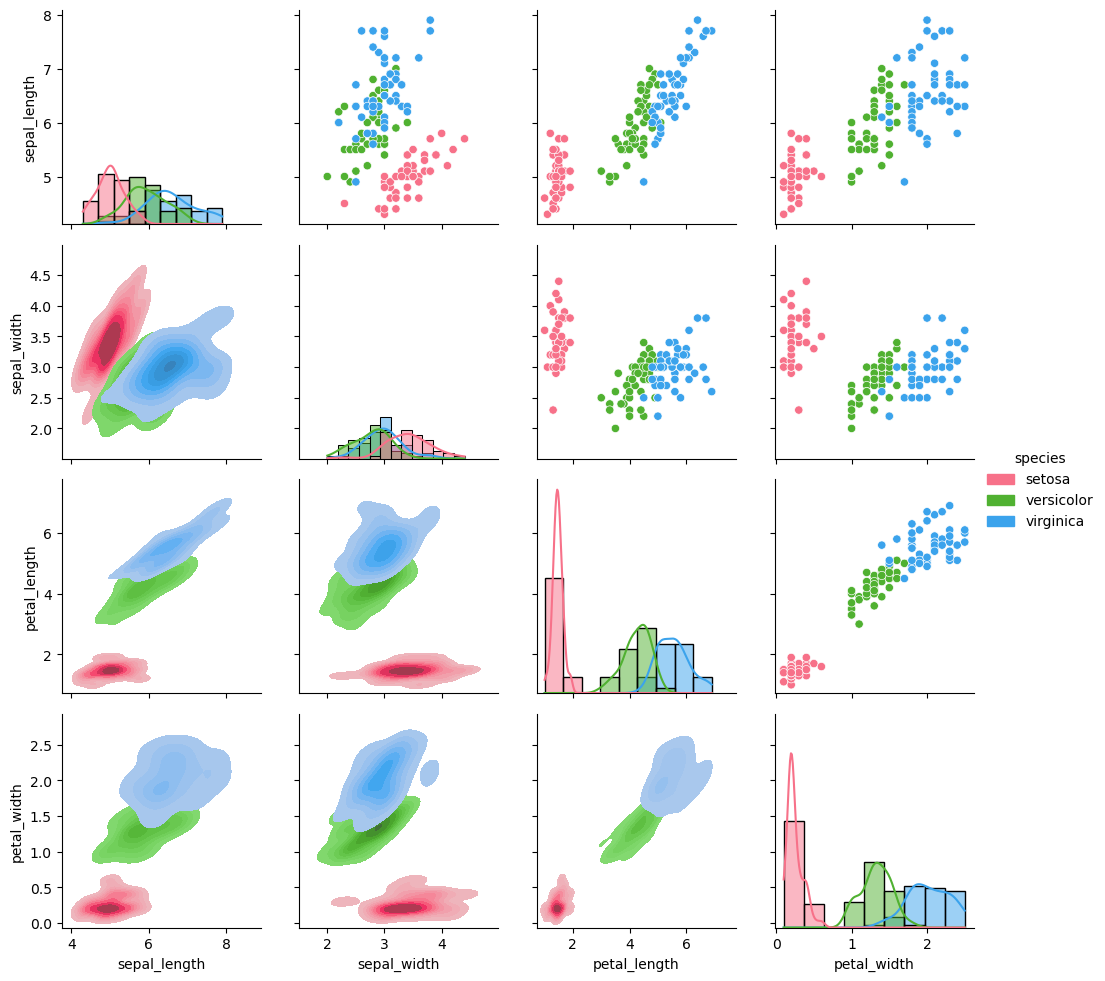

In [7]:
g = sns.PairGrid(iris, hue="species", palette="husl")

# Map plots to different sections of the grid
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)

# Add a legend
g.add_legend()

# Show plot
plt.show()

## 🗂️ FacetGrid

`FacetGrid` lets you create a matrix of plots based on the values of one or more categorical variables. It is ideal for creating small multiples — i.e., the same kind of plot repeated across different subsets of your dataset.

---

### ✅ Parameters

| Parameter      | Description                                                                |
| -------------- | -------------------------------------------------------------------------- |
| **`data`**     | DataFrame — your dataset                                                   |
| **`col`**      | Column name to facet across columns                                        |
| **`row`**      | Column name to facet across rows                                           |
| **`hue`**      | Column name to map color to variable                                       |
| **`palette`**  | Color palette for hue variable                                             |
| **`col_wrap`** | Number of columns before wrapping to next row (useful for long categories) |
| **`height`**   | Height (in inches) of each subplot                                         |
| **`aspect`**   | Aspect ratio (width / height) of each subplot                              |

---

### 🔄 Key Methods

| Method              | Description                                   |
| ------------------- | --------------------------------------------- |
| `map()`             | Maps a function to each subset of the data    |
| `map_dataframe()`   | Similar to `map`, but passes entire DataFrame |
| `add_legend()`      | Adds a legend for the `hue` variable          |
| `set_titles()`      | Customizes the facet titles                   |
| `set_axis_labels()` | Sets x and y axis labels                      |
| `facet_data()`      | Generator yielding each facet's data and axes |


### 🧠 When to Use `FacetGrid`

* You want to **compare subgroups** side by side.
* You have one or more **categorical variables** for faceting.
* You need a **grid of identical plots** across subsets of data.


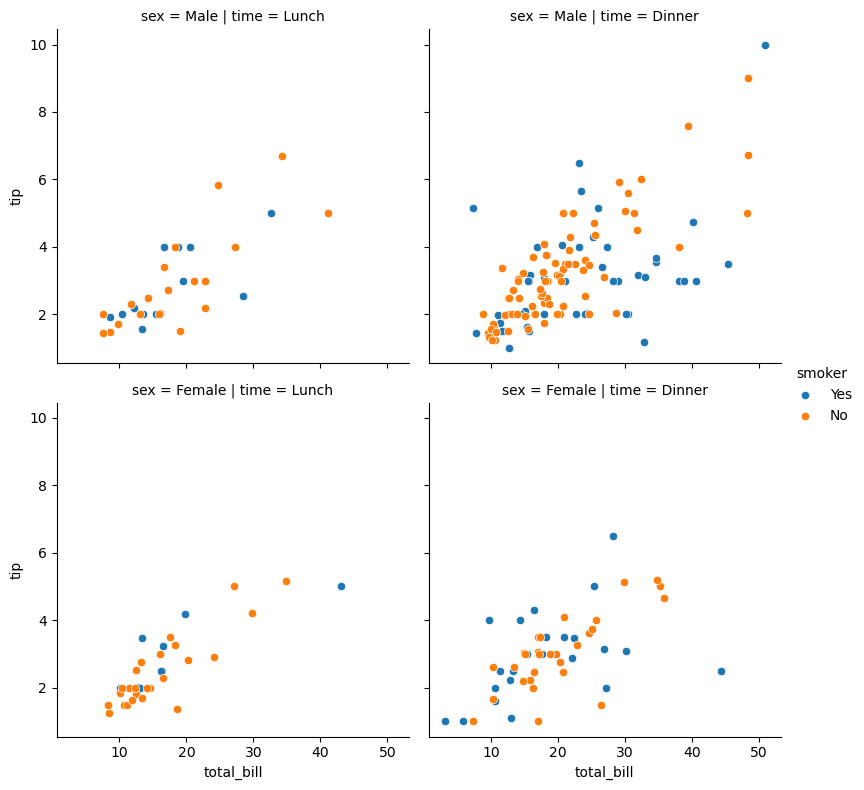

In [8]:
tips = sns.load_dataset("tips")

# Create a FacetGrid with rows and columns
g = sns.FacetGrid(tips, row="sex", col="time", hue="smoker", height=4)

# Map a scatterplot to each subset
g.map(sns.scatterplot, "total_bill", "tip")

# Add a legend
g.add_legend()

# Show plot
plt.show()

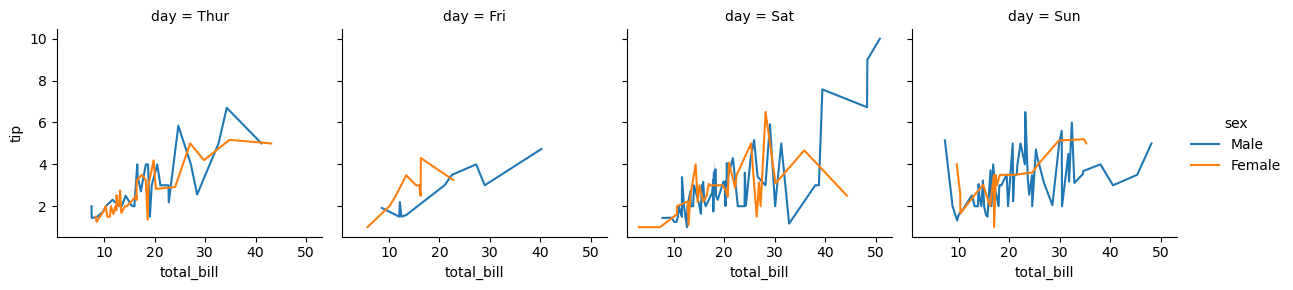

In [11]:
g = sns.FacetGrid(tips, col="day", hue="sex")
g.map_dataframe(sns.lineplot, x="total_bill", y="tip")
g.add_legend()
plt.show()

## 🔗 JointGrid

`JointGrid` sets up a **figure with a central plot** (e.g., scatter, regression) showing the relationship between two variables, and **marginal plots** (e.g., histograms, KDEs) showing the univariate distributions of each variable.

While `jointplot()` provides a quick and convenient way to create this structure, `JointGrid` offers deeper **customization** and **flexibility**.


### ✅ Parameters

| Parameter    | Description                                      |
| ------------ | ------------------------------------------------ |
| **`data`**   | DataFrame containing the data                    |
| **`x`**      | Name of variable for x-axis                      |
| **`y`**      | Name of variable for y-axis                      |
| **`height`** | Size (in inches) of the figure                   |
| **`ratio`**  | Ratio of joint axes size to marginal axes        |
| **`space`**  | Space between joint and marginal axes            |
| **`hue`**    | Variable in data for semantic mapping (optional) |

---

### 🔄 Key Methods

| Method              | Description                                        |
| ------------------- | -------------------------------------------------- |
| `plot()`            | Applies functions to both joint and marginal plots |
| `plot_joint()`      | Plots the central plot (e.g., scatter, regplot)    |
| `plot_marginals()`  | Plots the side histograms or KDEs                  |
| `set_axis_labels()` | Customizes axis labels                             |

---

### 🧠 When to Use `JointGrid`

* You want **detailed control** over the joint and marginal plots.
* You need to use **different functions** for the center and sides.
* You’re building **custom bivariate visualizations** with multiple semantic variables (like `hue`).



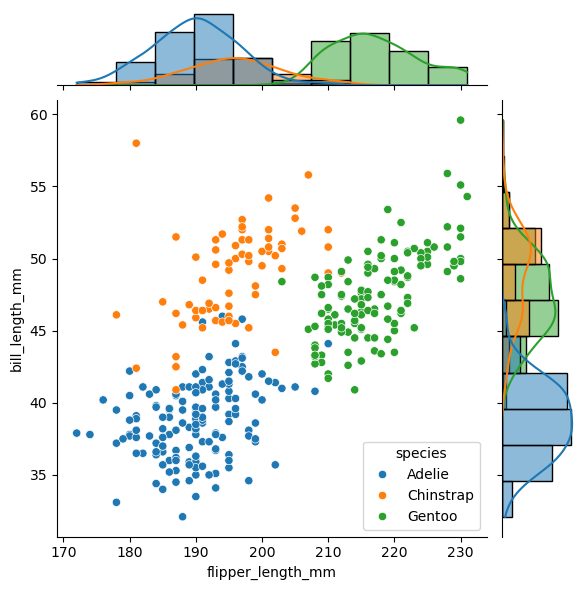

In [14]:
penguins = sns.load_dataset("penguins")

g = sns.JointGrid(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species")

g.plot_joint(sns.scatterplot)
g.plot_marginals(sns.histplot, kde=True)

plt.show()

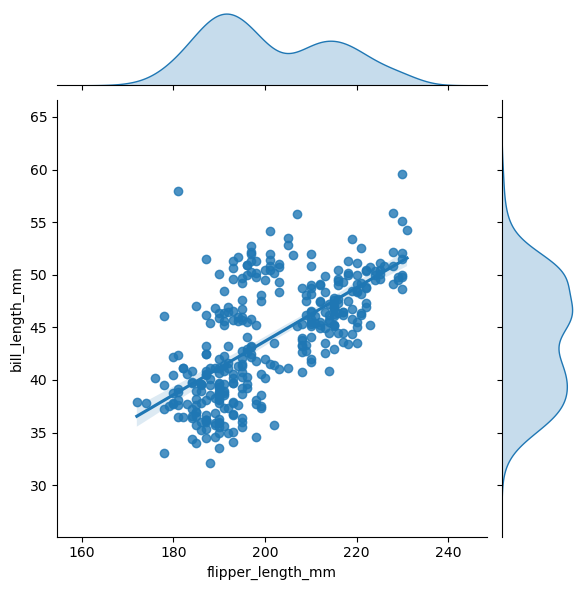

In [15]:
g = sns.JointGrid(data=penguins, x="flipper_length_mm", y="bill_length_mm")
g.plot_joint(sns.regplot)
g.plot_marginals(sns.kdeplot, fill=True)
plt.show()

## Styles

You can set particular styles:

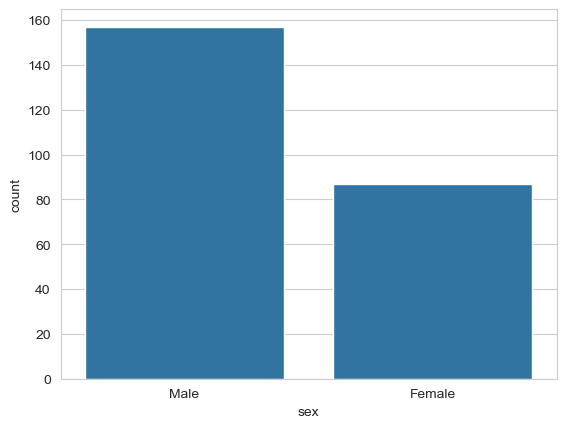

In [18]:
sns.set_style('whitegrid')
sns.countplot(x='sex',data=tips)
plt.show()

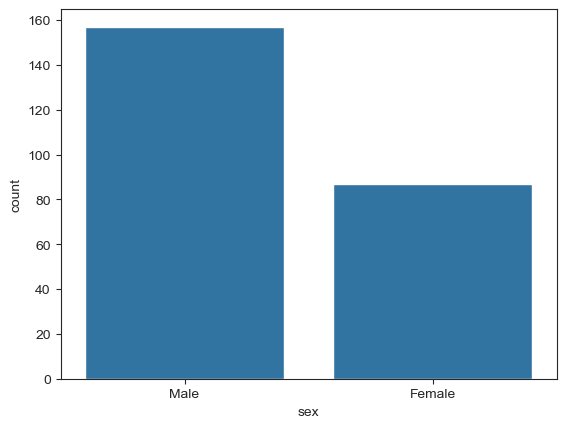

In [20]:
sns.set_style('ticks')
sns.countplot(x='sex',data=tips)
plt.show()

## Spine Removal

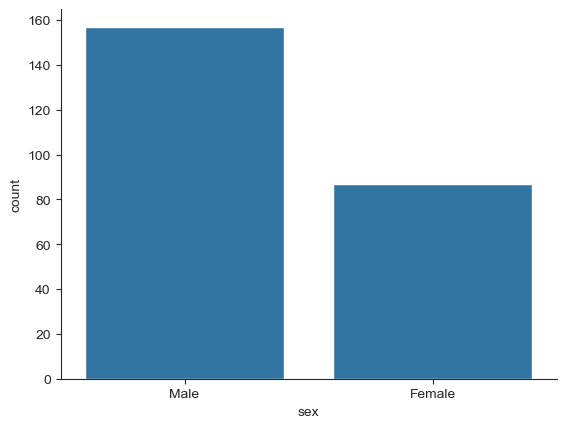

In [21]:
sns.countplot(x='sex',data=tips)
sns.despine()
plt.show()

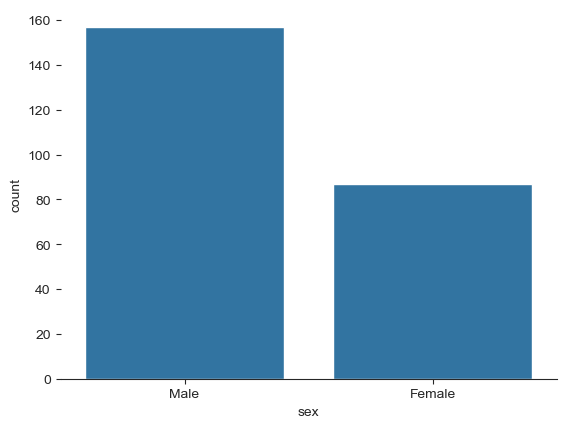

In [22]:
sns.countplot(x='sex',data=tips)
sns.despine(left=True)
plt.show()

## Size and Aspect

You can use matplotlib's **plt.figure(figsize=(width,height)** to change the size of most seaborn plots.

You can control the size and aspect ratio of most seaborn grid plots by passing in parameters: size, and aspect.

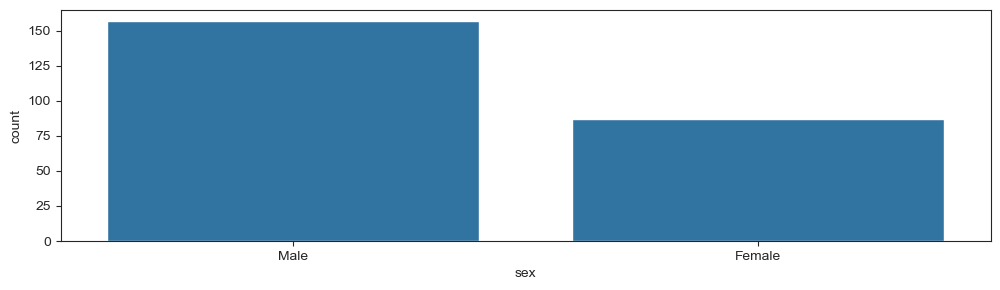

In [23]:
# Non Grid Plot
plt.figure(figsize=(12,3))
sns.countplot(x='sex',data=tips)
plt.show()

## Scale and Context

The set_context() allows you to override default parameters:

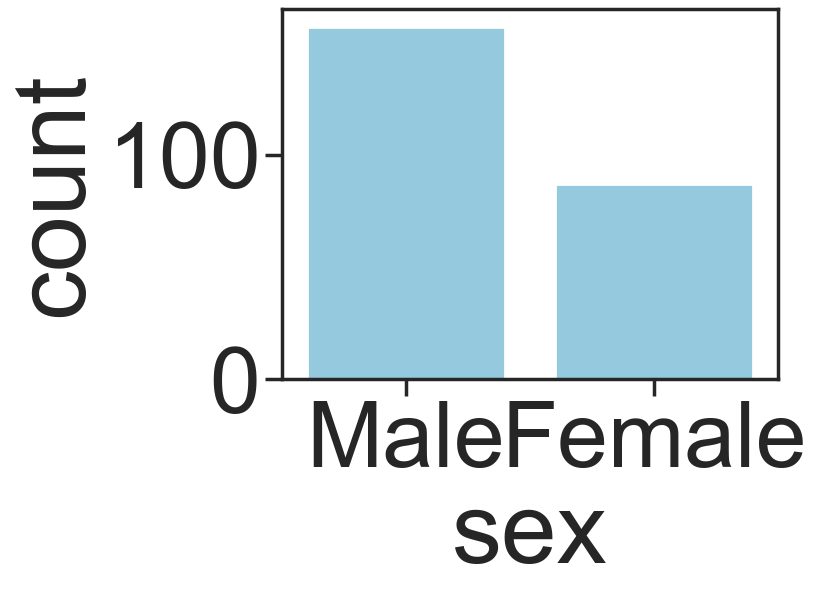

In [28]:
sns.set_context('poster',font_scale=3)
sns.countplot(x='sex',data=tips, color='skyblue')
plt.show()

# Great Job!


<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2008/Session%2008_4%20-%20Seaborn%20Exercises.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>